# 📘 Lecture 7: Discrete Distributions (Bernoulli, Binomial, Categorical, Multinomial), Logistic Regression, Softmax & Log-Sum-Exp Trick
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 7 - YouTube](https://youtu.be/RSCLyxg2ztM?si=XBNzulLFg2UMFkla)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we study discrete probability distributions and their central role in machine learning classification:
1. **Bernoulli & Binomial Distributions**: Modeling binary coin-toss outcomes $Y \in \{0, 1\}$ and generalizing across $N$ i.i.d. trials to count total successes $S$.
2. **Sigmoid (Logistic) Function & Binary Logistic Regression**: Mapping unconstrained linear logits $a = \mathbf{w}^\top \mathbf{x} + b$ to valid probabilities $\sigma(a) \in (0, 1)$, log-odds $\text{logit}(p) = \log \frac{p}{1-p}$, derivatives, and decision boundaries.
3. **Categorical & Multinomial Distributions**: Generalizing binary distributions to $C > 2$ discrete classes using one-hot representations $\mathbf{y} \in \{0, 1\}^C$ and multinomial coefficient counts.
4. **Softmax Function & Temperature Parameter**: Mapping logit vectors $\mathbf{a} \in \mathbb{R}^C$ to categorical probability distributions, analyzing temperature scaling ($T \to 0^+$ hard argmax vs. $T \to \infty$ uniform distribution).
5. **Multiclass Logistic Regression**: Parameter matrices $\mathbf{W} \in \mathbb{R}^{C \times D}$ and conditional cross-entropy loss.
6. **Log-Sum-Exp (LSE) Trick for Numerical Stability**: Resolving floating-point overflow (`inf`) when exponentiating large logits $a_c = 1000$ via $m = \max_c a_c$.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, statistics, and visualization packages.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Bernoulli & Binomial Distributions

### 1.1 Bernoulli Distribution
Models a single binary trial $Y \in \{0, 1\}$ (0: Failure/Tails, 1: Success/Heads) with success parameter $\theta = P(Y=1) \in [0, 1]$:
$$P(Y = y \mid \theta) = \text{Ber}(y \mid \theta) = \theta^y (1 - \theta)^{1-y} = \theta^{\mathbb{I}(y=1)} (1 - \theta)^{\mathbb{I}(y=0)}$$
- Expectation: $\mathbb{E}[Y] = \theta$
- Variance: $\text{Var}(Y) = \theta (1 - \theta)$

### 1.2 Binomial Distribution
Generalizes Bernoulli across $N$ i.i.d. trials. Total successes $S = \sum_{i=1}^N Y_i \in \{0, 1, \dots, N\}$:
$$P(S = s \mid N, \theta) = \text{Bin}(s \mid N, \theta) = \binom{N}{s} \theta^s (1 - \theta)^{N-s}, \quad \text{where } \binom{N}{s} = \frac{N!}{s!(N-s)!}$$
- Expectation: $\mathbb{E}[S] = N \theta$
- Variance: $\text{Var}(S) = N \theta (1 - \theta)$


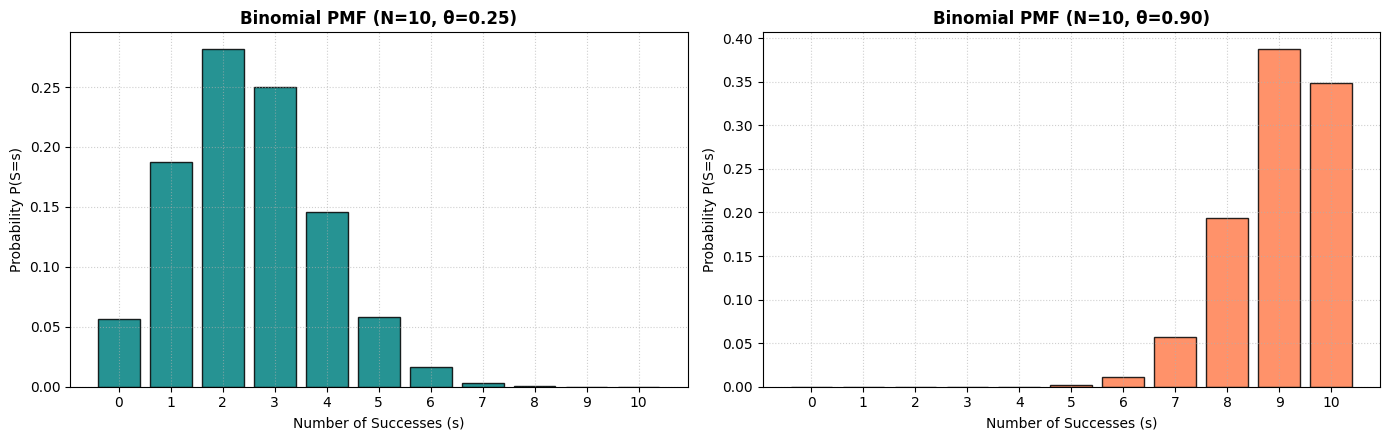

📊 Binomial Theoretical Moments:
   θ=0.25 -> Expected Mean E[S] = 2.50, Variance Var(S) = 1.88
   θ=0.90 -> Expected Mean E[S] = 9.00, Variance Var(S) = 0.90


In [2]:
##Write code here..
#We define trials and range of succeses
N_trials = 10
s_vals = np.arange(0,N_trials+1)

#calculate the probability mass function (PMF) using scipy
pmf_theta_25 = stats.binom.pmf(s_vals, N_trials, 0.25)
pmf_theta_90 = stats.binom.pmf(s_vals, N_trials, 0.90)

#End code here..

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot 1: Binomial(N=10, p=0.25)
axes[0].bar(s_vals, pmf_theta_25, color='teal', alpha=0.85, edgecolor='black')
axes[0].set_title('Binomial PMF (N=10, θ=0.25)', fontweight='bold')
axes[0].set_xlabel('Number of Successes (s)')
axes[0].set_ylabel('Probability P(S=s)')
axes[0].set_xticks(s_vals)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Binomial(N=10, p=0.90)
axes[1].bar(s_vals, pmf_theta_90, color='coral', alpha=0.85, edgecolor='black')
axes[1].set_title('Binomial PMF (N=10, θ=0.90)', fontweight='bold')
axes[1].set_xlabel('Number of Successes (s)')
axes[1].set_ylabel('Probability P(S=s)')
axes[1].set_xticks(s_vals)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("📊 Binomial Theoretical Moments:")
print(f"   θ=0.25 -> Expected Mean E[S] = {N_trials*0.25:.2f}, Variance Var(S) = {N_trials*0.25*0.75:.2f}")
print(f"   θ=0.90 -> Expected Mean E[S] = {N_trials*0.90:.2f}, Variance Var(S) = {N_trials*0.90*0.10:.2f}")


## 2️⃣ Sigmoid (Logistic) Function & Binary Logistic Regression

### 2.1 Why Not Linear Regression for Classification?
Linear regression predicts unconstrained continuous outputs $f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b \in (-\infty, \infty)$. This produces invalid probabilities $< 0$ or $> 1$.

### 2.2 Sigmoid Function & Log-Odds
To map logits $a = \mathbf{w}^\top \mathbf{x} + b$ to valid probability parameters $\theta \in (0, 1)$, we apply the **Sigmoid Logistic Function**:
$$\theta = \sigma(a) = \frac{1}{1 + e^{-a}} = \frac{e^a}{1 + e^a}$$

Inverting $\theta = \sigma(a)$ yields the **Log-Odds (Logit)** function:
$$\text{logit}(p) = \log\left( \frac{p}{1 - p} \right) = a$$

### 2.3 Mathematical Properties
1. Symmetry: $\sigma(-a) = 1 - \sigma(a)$
2. Derivative: $\frac{d}{da} \sigma(a) = \sigma(a)(1 - \sigma(a))$
3. Softplus Integration: $\text{softplus}(a) = \log(1 + e^a), \quad \frac{d}{da}\text{softplus}(a) = \sigma(a)$


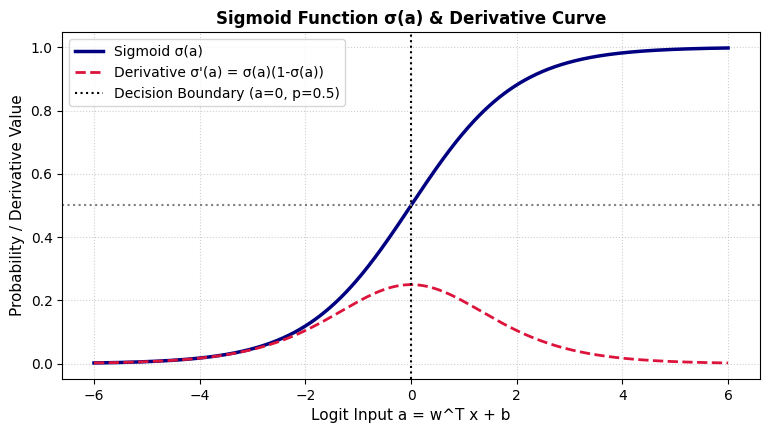

In [3]:
#Start code here..
#We implement the sigmoid S-curve function
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))

#Implement the derivate of sigmoid for gradient based learning
def d_sigmoid(a):
    s = sigmoid(a)
    return s * (1-s)

#End code here..
a_vals = np.linspace(-6, 6, 500)


plt.figure(figsize=(9, 4.5))
plt.plot(a_vals, sigmoid(a_vals), color='navy', linewidth=2.5, label='Sigmoid σ(a)')
plt.plot(a_vals, d_sigmoid(a_vals), color='crimson', linestyle='--', linewidth=2, label="Derivative σ'(a) = σ(a)(1-σ(a))")
plt.axvline(0, color='black', linestyle=':', label='Decision Boundary (a=0, p=0.5)')
plt.axhline(0.5, color='gray', linestyle=':')
plt.xlabel('Logit Input a = w^T x + b', fontsize=11)
plt.ylabel('Probability / Derivative Value', fontsize=11)
plt.title('Sigmoid Function σ(a) & Derivative Curve', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 3️⃣ Categorical & Multinomial Distributions

### 3.1 Categorical Distribution
Generalizes Bernoulli to $C > 2$ discrete categories ($Y \in \{1, 2, \dots, C\}$). Represented using a One-Hot vector $\mathbf{y} \in \{0, 1\}^C$ where $\sum_{c=1}^C y_c = 1$.
$$P(\mathbf{y} \mid \boldsymbol{\theta}) = \text{Cat}(\mathbf{y} \mid \boldsymbol{\theta}) = \prod_{c=1}^C \theta_c^{y_c}, \quad \text{where } \theta_c \ge 0, \quad \sum_{c=1}^C \theta_c = 1$$

### 3.2 Multinomial Distribution
Generalizes Categorical across $N$ i.i.d. trials. Count vector $\mathbf{n} = [n_1, n_2, \dots, n_C]^\top$ where $\sum_{c=1}^C n_c = N$:
$$P(\mathbf{n} \mid N, \boldsymbol{\theta}) = \binom{N}{n_1, n_2, \dots, n_C} \prod_{c=1}^C \theta_c^{n_c} = \frac{N!}{n_1! n_2! \dots n_C!} \prod_{c=1}^C \theta_c^{n_c}$$


In [5]:
#Start code here..
#Define probabilities for a fair die (categorical parameters)
theta_die = np.array([1/6,1/6,1/6,1/6,1/6,1/6])
N_rolls = 6000

#Simulate N trials (Multinomial counts)
multinomial_counts = np.random.multinomial(n=N_rolls, pvals=theta_die)

#Orgainze the results into a dataframe for visualization
df_multinomial = pd.DataFrame({
    'Die Face (Category)': [f'Face {i+1}' for i in range(6)],
    'Target probability (θ_c)': theta_die,
    'Empirical Count (n_c)': multinomial_counts,
    'Empirical Proportion': multinomial_counts / N_rolls
})

#End code here..

print(f"🎲 Multinomial Simulation of Rolling a Die N={N_rolls:,} Times:")
print(df_multinomial.to_string(index=False))


🎲 Multinomial Simulation of Rolling a Die N=6,000 Times:
Die Face (Category)  Target probability (θ_c)  Empirical Count (n_c)  Empirical Proportion
             Face 1                  0.166667                   1004              0.167333
             Face 2                  0.166667                    993              0.165500
             Face 3                  0.166667                   1017              0.169500
             Face 4                  0.166667                   1033              0.172167
             Face 5                  0.166667                    978              0.163000
             Face 6                  0.166667                    975              0.162500


## 4️⃣ Softmax Function & Temperature Parameter

### 4.1 Softmax Formulation
For multi-class classification, input logit vector $\mathbf{a} = [a_1, a_2, \dots, a_C]^\top \in \mathbb{R}^C$ is mapped to a probability distribution via Softmax:
$$\text{softmax}_c(\mathbf{a}) = \frac{e^{a_c}}{\sum_{c'=1}^C e^{a_{c'}}}$$

### 4.2 Temperature Parameter Scaling
Introducing a temperature parameter $T > 0$:
$$\text{softmax}_c(\mathbf{a} / T) = \frac{e^{a_c / T}}{\sum_{c'=1}^C e^{a_{c'} / T}}$$
- **Low Temperature ($T \to 0^+$)**: Amplifies logit differences, approaching a hard one-hot $\arg\max$.
- **High Temperature ($T \to \infty$)**: Smooths differences, approaching a uniform distribution $1/C$.


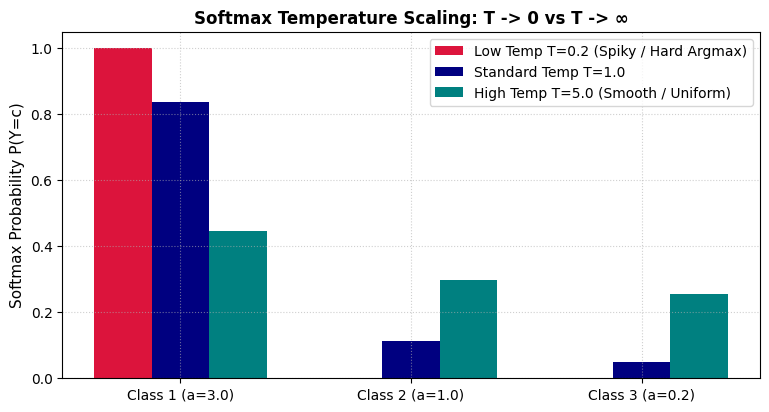

In [6]:
# Visual Demonstration of Softmax Temperature Scaling
#Start code here..
#define a softmax with a temperature parameter T
def softmax_temp(logits, T=1.0):
    scaled_logits = logits / T
    #subtract max for numerical stability (prevent overflow)
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    return exp_logits / np.sum(exp_logits)

logits_sample = np.array([3.0,1.0,0.2])
classes = ['Class 1 (a=3.0)', 'Class 2 (a=1.0)', 'Class 3 (a=0.2)']

#compare the effects of different temperatures
t_low = softmax_temp(logits_sample, T=0.2) #it concentratres probability on the largest logit values
t_mid = softmax_temp(logits_sample, T=1.0) #standard softmax
t_high = softmax_temp(logits_sample, T=5.0)  #it tires to make the probability distribution more uniform in nature

x_indices = np.arange(len(classes))
width = 0.25

#End code here..

plt.figure(figsize=(9, 4.5))
plt.bar(x_indices - width, t_low, width=width, color='crimson', label='Low Temp T=0.2 (Spiky / Hard Argmax)')
plt.bar(x_indices, t_mid, width=width, color='navy', label='Standard Temp T=1.0')
plt.bar(x_indices + width, t_high, width=width, color='teal', label='High Temp T=5.0 (Smooth / Uniform)')

plt.xticks(x_indices, classes)
plt.ylabel('Softmax Probability P(Y=c)', fontsize=11)
plt.title('Softmax Temperature Scaling: T -> 0 vs T -> ∞', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 5️⃣ Log-Sum-Exp (LSE) Trick for Numerical Stability

### 5.1 Floating-Point Overflow Hazard
When evaluating $e^{a_c}$ for large logits (e.g. $a_c = 1000$), standard floating-point arithmetic overflows: $e^{1000} \to \text{inf}$, causing NaN results.

### 5.2 Log-Sum-Exp Identity
Let $m = \max_c a_c$. We factor $e^m$ out of the sum:
$$\text{LSE}(\mathbf{a}) = \log \sum_{c=1}^C e^{a_c} = \log \left( e^m \sum_{c=1}^C e^{a_c - m} \right) = m + \log \sum_{c=1}^C e^{a_c - m}$$

Since $a_c - m \le 0$, $e^{a_c - m} \in (0, 1]$, completely eliminating floating-point overflow!

### 5.3 Numerically Stable Log-Softmax
$$\log \text{softmax}_c(\mathbf{a}) = a_c - \text{LSE}(\mathbf{a})$$


In [7]:
#Start code here..
#set the inputs that normally cause overflow in standard float64
large_logits = np.array([1000.0, 1001.0, 999.0])
#attempting to do naive computation (which should fail)
try:
  naive_exp = np.exp(large_logits)
  naive_softmax = naive_exp / np.sum(naive_exp)
except Exception as e:
  naive_softmax = "Overflow Error"

#LSE Trick : log(sum(exp(A))) = m + log(sum(exp(A-m)))
def log_sum_exp(logits):
    m = np.max(logits)
    return m + np.log(np.sum(np.exp(logits-m)))

#Stable softmax using LSE identity
def stable_softmax(logits):
    lse = log_sum_exp(logits)
    return np.exp(logits - lse)

stable_result = stable_softmax(large_logits)

print("Log-Sum-Exp numerical stability comparison")
print(f"Large Input logits : {large_logits}")
print(f"Naive exponential logits : {np.exp(large_logits[0])} (Inf!)")
print(f"LSE value: {log_sum_exp(large_logits):.4f}")
print(f"Stable softmax: {stable_result.round(4)}")



#End code here..

Log-Sum-Exp numerical stability comparison
Large Input logits : [1000. 1001.  999.]
Naive exponential logits : inf (Inf!)
LSE value: 1001.4076
Stable softmax: [0.2447 0.6652 0.09  ]


/tmp/ipykernel_7218/3186924877.py:6: RuntimeWarning: overflow encountered in exp
  naive_exp = np.exp(large_logits)
/tmp/ipykernel_7218/3186924877.py:7: RuntimeWarning: invalid value encountered in divide
  naive_softmax = naive_exp / np.sum(naive_exp)
/tmp/ipykernel_7218/3186924877.py:25: RuntimeWarning: overflow encountered in exp
  print(f"Naive exponential logits : {np.exp(large_logits[0])} (Inf!)")
